# 04 — อคติกรอบเวลาใหญ่ 4H (Higher-Timeframe Bias)

แสดงทิศทางอคติ (`long` / `short` / `neutral`) ที่ผลิตหนึ่งค่าต่อแท่ง 4H ซ้อนทับบนซีรีส์ continuous
เครื่องมือนี้ใช้ **กรอง (veto)** ไม้ที่สวนเทรนด์เท่านั้น — ไม่ได้สร้างสัญญาณเข้าเอง

**หมายเหตุ (4h = mirror-only):** แหล่งข้อมูล `engine` ยังไม่รองรับ 4h (`EngineTimeframeUnavailableError`,
ไม่มี local rollup — D10) จึงต้องอ่าน `data/continuous/4h.parquet` จากแหล่ง `mirror` ซึ่ง data-gated
บน `TVKIT_AUTH_TOKEN` จริงเหมือน Phase 1/2 — รัน `scripts/visualise_bias.py` ก่อนเพื่อสร้าง artifact
ที่ปลอดภัยสาธารณะ (ไม่มีคอลัมน์ OHLCV ดิบ)

In [1]:
from pathlib import Path

import polars as pl

from tfex_s50_multi_tf_swing.bias.htf import build_bias_inputs, classify_frame
from tfex_s50_multi_tf_swing.config.settings import get_settings
from tfex_s50_multi_tf_swing.data.store import ParquetStore

In [2]:
# Build the 4H bias overlay from the mirror-sourced continuous series.
settings = get_settings()
store = ParquetStore(settings.data_dir)
continuous = store.read_continuous("4h")

inputs = build_bias_inputs(continuous, "4h", regime_thresholds=settings.regime_thresholds())
bias = classify_frame(inputs, config=settings.bias_config())
bias.select("time", "bias_direction").head()

time,bias_direction
"datetime[μs, UTC]",str
2016-06-03 04:00:00 UTC,"""neutral"""
2016-06-03 08:00:00 UTC,"""neutral"""
2016-06-06 00:00:00 UTC,"""neutral"""
2016-06-06 04:00:00 UTC,"""neutral"""
2016-06-06 08:00:00 UTC,"""neutral"""


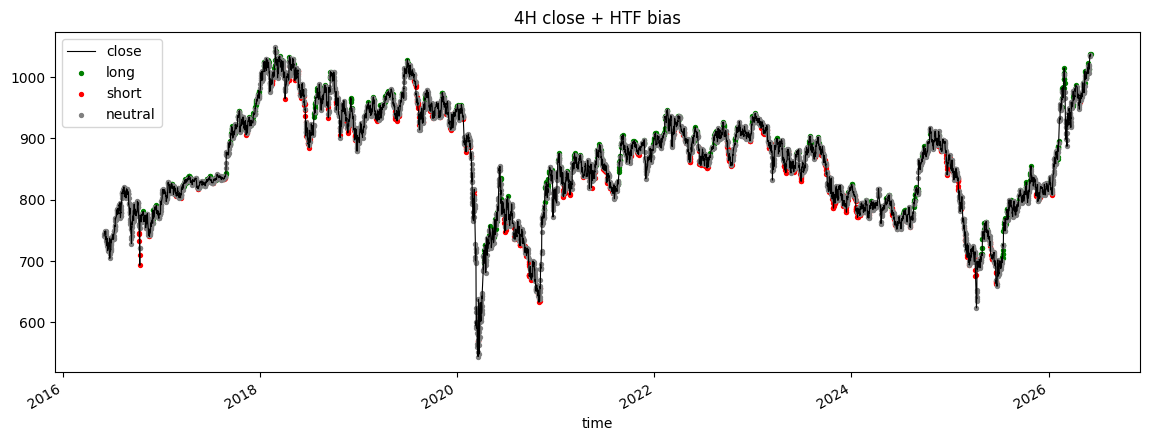

In [3]:
# Public-safe overlay: join bias direction onto close for plotting (close kept local only).
overlay = continuous.select("time", pl.col("close").cast(pl.Float64)).join(
    bias.select("time", "bias_direction"), on="time", how="inner"
)

_pdf = overlay.to_pandas().set_index("time")
ax = _pdf["close"].plot(figsize=(14, 5), color="black", lw=0.8, title="4H close + HTF bias")
colours = {"long": "green", "short": "red", "neutral": "grey"}
for direction, colour in colours.items():
    mask = _pdf["bias_direction"] == direction
    ax.scatter(_pdf.index[mask], _pdf["close"][mask], s=8, color=colour, label=direction)
ax.legend()

## สรุป

- จุดสีเขียว/แดง/เทา = อคติ `long`/`short`/`neutral` ของแต่ละแท่ง 4H
- ช่วง `panic` หรือ `range_low_vol` จะถูกบังคับเป็น `neutral` (veto) เสมอ
- เกณฑ์ §4.3 (ลดไม้สวนเทรนด์ ≥ 30%) เลื่อนไป Phase 5 (ชั้น signals) — ดู `scripts/bias_counter_trend_demo.py`